## Citation Network Node Classification — Exploration

In [1]:
import sys
sys.path.append('../src')

import torch
import matplotlib.pyplot as plt

from data_loader import load_dataset
import graph_analysis as ga


/Users/justelis/bigdata_project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the dataset

In [2]:
dataset, data = load_dataset('Cora', root='../data')
print('Features:', dataset.num_features, ', classes:', dataset.num_classes)
data

Features: 1433 , classes: 7


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

## 2. Structural analysis


In [3]:
ga.print_report(data, 'Cora')


Data Analysis: Cora
Nodes:          2708
Edges:          10556
Average degree: 3.9

Class distribution:
-class 0: 351
-class 1: 217
-class 2: 418
-class 3: 818
-class 4: 426
-class 5: 298
-class 6: 180

Edge types:
-intra-class edges: 8550
-inter-class edges: 2006
-intra-class ratio: 0.81


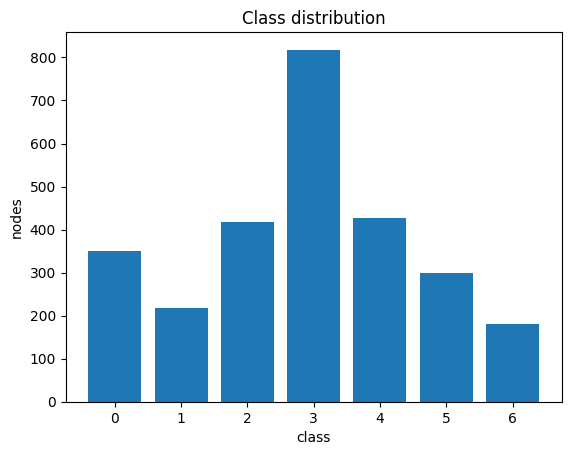

In [9]:
dist = ga.class_distribution(data)
plt.bar([str(k) for k in dist.keys()], list(dist.values()))
plt.xlabel('class'); plt.ylabel('nodes'); plt.title('Class distribution')
plt.show()

## 3. Compare baselines and GNNs

In [6]:
from logreg_baseline import run_logistic_regression
from mlp_baseline import MLP
from gcn import GCN
from graph_sage import GraphSAGE
from gat import GAT
from train import train_model

torch.manual_seed(42)
inc, outc = dataset.num_features, dataset.num_classes

results = {'LogReg': run_logistic_regression(data)['test']}
models = {
    'MLP': MLP(inc, 64, outc),
    'GCN': GCN(inc, 64, outc),
    'GraphSAGE': GraphSAGE(inc, 64, outc),
    'GAT': GAT(inc, 64, outc),
}
for name, m in models.items():
    results[name] = train_model(m, data, epochs=200)['best_test_acc']

for name, acc in results.items():
    print(f'{name:<12} {acc:.4f}')

LogReg       0.5760
MLP          0.5700
GCN          0.8060
GraphSAGE    0.8030
GAT          0.8130


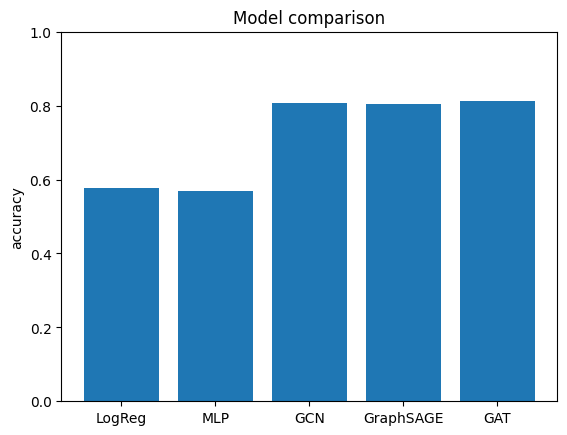

In [8]:
plt.bar(list(results.keys()), list(results.values()))
plt.ylabel('accuracy'); plt.title('Model comparison'); plt.ylim(0, 1)
plt.show()

## 4. t-SNE

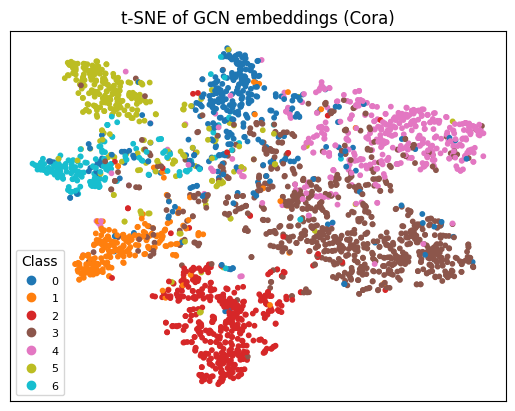

In [10]:
from sklearn.manifold import TSNE

gcn = GCN(inc, 64, outc)
train_model(gcn, data, epochs=200)
gcn.eval()
with torch.no_grad():
    emb = gcn.embed(data.x, data.edge_index).numpy()

emb2d = TSNE(n_components=2, init='pca', random_state=42).fit_transform(emb)
sc = plt.scatter(emb2d[:,0], emb2d[:,1], c=data.y.numpy(), cmap='tab10', s=10)
plt.legend(*sc.legend_elements(), title='Class', fontsize=8)
plt.xticks([]); plt.yticks([]); plt.title('t-SNE of GCN')
plt.show()